# 📘 Review — Aula 02: do Pré-Cálculo à SVM, e do código lento ao código otimizado

> Notebook de revisão em **três partes**:
> **1.** a teoria completa, construída a partir do pré-cálculo; **2.** como o código antigo funcionava; **3.** como o novo código funciona e por que é melhor — sempre amarrando código e matemática.
>
> **Pré-requisito assumido:** apenas pré-cálculo (funções, retas, gráficos, exponenciais). Todo conceito de cálculo e álgebra linear é construído aqui do zero e imediatamente aplicado a Machine Learning.

## Índice

1. **Parte 1 — Teoria**
   - 1.0 Dicionário de notação matemática
   - 1.1 Funções, retas e taxa de variação
   - 1.2 Derivadas, regras básicas e regra da cadeia
   - 1.3 Regressão linear com uma variável (modelo + custo MSE)
   - 1.4 Derivadas parciais, gradiente e direção de descida
   - 1.5 Gradient Descent em lote
   - 1.6 Álgebra linear mínima: vetores, normas, produto escalar
   - 1.7 Matrizes e a forma vetorizada $X w$
   - 1.8 Classificador linear, hiperplanos e margem (funcional e geométrica)
   - 1.9 Perceptron
   - 1.10 SGD e mini-batch
   - 1.11 SVM linear: motivação, hinge loss, subgradiente e vetores de suporte
2. **Parte 2 — O código antigo**
3. **Parte 3 — O código novo e por que ele é melhor**
4. **Validação final — cenários de estresse e critérios de aceite**

## 1.0 — Dicionário de notação matemática (leia antes de prosseguir)

Antes de qualquer fórmula, combine a notação. É o "alfabeto" que usaremos até o fim do notebook:

| Símbolo | Significado | Exemplo |
|---|---|---|
| $x$, $y$, $t$ | escalares (números soltos) | $x = 3{,}2$ |
| $\mathbf{x}$, $\mathbf{w}$ | vetores (listas de números em coluna) | $\mathbf{x} = (x_1, x_2)$ |
| $x_j$ | a $j$-ésima entrada do vetor $\mathbf{x}$ | $x_1 = 3{,}2$ |
| $x^{(i)}$ | a $i$-ésima **amostra** do dataset | a 1ª resenha do CSV |
| $y_i$ | o **rótulo** da amostra $i$ | $y_i \in \{-1, +1\}$ |
| $X$ | **matriz** com as amostras nas linhas | $m$ linhas $\times$ $d$ colunas |
| $\cdot$ | **produto interno** | $\mathbf{w}\cdot\mathbf{x} = \sum_j w_j x_j$ |
| $\|\mathbf{x}\|$ | **norma** (comprimento do vetor) | $\sqrt{x_1^2 + x_2^2}$ |
| $\sum_{i=1}^{m}$ | **somatório** | $\sum_{i=1}^{3} i = 1+2+3 = 6$ |
| $\max(0, z)$ | "o maior entre 0 e z" (nunca negativo) | $\max(0,-2)=0$ |
| $\operatorname{sign}(z)$ | **sinal** de um número | $+1$ se $z>0$, $-1$ se $z<0$ |
| $\frac{\partial J}{\partial w}$ | **derivada parcial** de $J$ em relação a $w$ | "como $J$ muda ao mexer só em $w$" |
| $\nabla J$ | **gradiente** (vetor de todas as parciais) | $\nabla J = (\frac{\partial J}{\partial w_0}, \frac{\partial J}{\partial w_1})$ |
| $\arg\min_w J(w)$ | o valor de $w$ que **minimiza** $J$ | "onde fica o fundo da tigela" |
| $\leftarrow$ | **"recebe"** (atualização de variável) | $w \leftarrow w + \Delta$ |

Convenções que evitam 90% das confusões:

- Uma amostra é um vetor $\mathbf{x}$; o dataset inteiro é a matriz $X$ (uma amostra por linha).
- Os **pesos** do modelo são $\mathbf{w}$ (no código da aula: `theta`) e o **viés** é $b$ (no código: `theta_0`).
- Os **rótulos** são $y_i \in \{-1, +1\}$: é o sinal que carrega a classe.
- Produto interno escrito de três formas equivalentes: $\mathbf{w}\cdot\mathbf{x} = \sum_j w_j x_j = \mathbf{w}^\top \mathbf{x}$.

> **Sobre siglas:** nesta aula o protagonista é a **SVM** (Support Vector Machine). **SVD** (Decomposição em Valores Singulares) é outra coisa — uma fatoração de matrizes usada em PCA/recomendação, assunto de aulas futuras. Aqui só precisamos de $X\mathbf{w}$.

## 1.1 — Pré-cálculo aplicado: funções, retas e taxa de variação

Tudo em Machine Learning começa com **funções**. Uma função $f$ é uma regra que transforma uma entrada em uma saída. Na aula, os "modelos" são justamente funções que transformam dados em previsões.

A função mais simples e mais importante para nós é a **função afim** (reta):

$$
f(x) = a\,x + b
$$

onde $a$ é o **coeficiente angular** (a inclinação) e $b$ o **coeficiente linear** (onde a reta corta o eixo $y$).

- A **taxa média de variação** de $f$ entre $x_0$ e $x_0 + h$ mede o quanto $f$ muda por unidade de $x$:

$$
\frac{\Delta f}{\Delta x} = \frac{f(x_0 + h) - f(x_0)}{h}
$$

- Graficamente, isso é a **inclinação da reta secante** que liga os dois pontos.
- Aplicação em ML: o modelo linear $\hat y = w x + b$ é uma função afim; o peso $w$ é a inclinação — ele diz "o quanto a previsão muda quando a entrada muda". Ajustar $w$ e $b$ é literalmente "escolher a melhor reta".

Na célula abaixo vemos a secante se aproximar da **reta tangente** quando $h$ fica pequeno — essa é a ponte para o Cálculo.

In [15]:
# ============================================================
# SEÇÃO 1 — Configuração, dados sintéticos e utilitários
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import time

plt.rcParams.update({
    "figure.dpi": 100,
    "font.size": 11,
    "axes.grid": True,
    "mathtext.fontset": "cm",
})

# Semente fixa -> resultados reproduzíveis
rng = np.random.default_rng(42)

# ------------------------------------------------------------
# Dataset sintético LINEARMENTE SEPARÁVEL (duas classes, 2D)
# Clusters próximos o bastante para o perceptron levar algumas
# épocas aprendendo (mais didático do que dados fáceis demais).
# ------------------------------------------------------------
n_pts = 60
X_neg = rng.normal(loc=[-1.1, -1.1], scale=1.0, size=(n_pts, 2))
X_pos = rng.normal(loc=[ 1.1,  1.1], scale=1.0, size=(n_pts, 2))
X_2d = np.vstack([X_neg, X_pos])
y_2d = np.concatenate([-np.ones(n_pts), np.ones(n_pts)])

# ------------------------------------------------------------
# Utilitários de plotagem (reutilizados no notebook inteiro)
# ------------------------------------------------------------
def plot_dados(ax, X, y, titulo="Dados"):
    """Pontos de duas classes com rótulos -1 e +1."""
    ax.scatter(X[y == -1, 0], X[y == -1, 1], c="crimson",
               label="classe -1", edgecolors="k", alpha=0.8)
    ax.scatter(X[y == +1, 0], X[y == +1, 1], c="steelblue",
               label="classe +1", edgecolors="k", alpha=0.8)
    ax.set_title(titulo)
    ax.legend()
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")

def plot_reta(ax, w, b, xmin, xmax, cor="black", rotulo=None, **kw):
    """Desenha a reta w·x + b = 0 no intervalo [xmin, xmax]."""
    xs = np.array([xmin, xmax])
    ys = -(w[0] * xs + b) / w[1]          # w1 x1 + w2 x2 + b = 0
    ax.plot(xs, ys, color=cor, label=rotulo, **kw)

print("Configuração pronta. Dataset:", X_2d.shape, "rótulos:", y_2d.shape)

Configuração pronta. Dataset: (120, 2) rótulos: (120,)


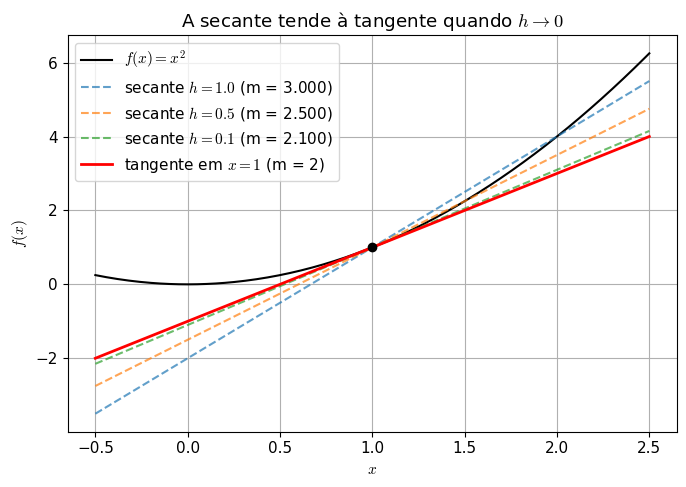

In [2]:
# Reta secante tendendo à reta tangente em x0 = 1, para f(x) = x^2
f = lambda x: x**2
x0 = 1.0
hs = [1.0, 0.5, 0.1]                     # distâncias h cada vez menores

xs = np.linspace(-0.5, 2.5, 300)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(xs, f(xs), "k-", label="$f(x)=x^2$")
for h in hs:
    m = (f(x0 + h) - f(x0)) / h          # inclinação da SECANTE
    ax.plot(xs, m*(xs - x0) + f(x0), ls="--", alpha=0.7,
            label=f"secante $h={h}$ (m = {m:.3f})")
ax.plot(xs, 2*x0*(xs - x0) + f(x0), "r-", lw=2,
        label="tangente em $x=1$ (m = 2)")
ax.scatter([x0], [f(x0)], color="k", zorder=5)
ax.set_title("A secante tende à tangente quando $h \\to 0$")
ax.legend()
ax.set_xlabel("$x$")
ax.set_ylabel("$f(x)$")
plt.tight_layout()
plt.show()

## 1.2 — Derivadas, regras básicas e regra da cadeia

A **derivada** é o limite da taxa média de variação quando $h \to 0$:

$$
f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}
$$

Intuição: é a inclinação da **reta tangente** — a taxa de variação *instantânea*. Para minimizar uma função, o **sinal** da derivada diz a direção:

- $f'(x) > 0$: a função está subindo → ande para a **esquerda**;
- $f'(x) < 0$: a função está descendo → ande para a **direita**.

**Regras básicas** (basta decorar estas):

| Regra | Fórmula |
|---|---|
| Potência | $(x^n)' = n\, x^{n-1}$ |
| Soma | $(f + g)' = f' + g'$ |
| Produto por constante | $(c f)' = c f'$ |
| Cadeia (composição) | $(f \circ g)'(x) = f'(g(x)) \cdot g'(x)$ |

**A regra da cadeia em ML:** toda rede neural é uma *composição* de funções, e o treinamento calcula a "sensibilidade do erro a cada parâmetro" encadeando derivadas de trás para frente — isso é o famoso *backpropagation*. Aqui ela aparece já na regressão: o custo depende dos pesos através da previsão $h(x) = wx + b$; a derivada do custo em relação a $w$ usa a cadeia: $\frac{\partial J}{\partial w} = \frac{\partial J}{\partial h} \cdot \frac{\partial h}{\partial w}$.

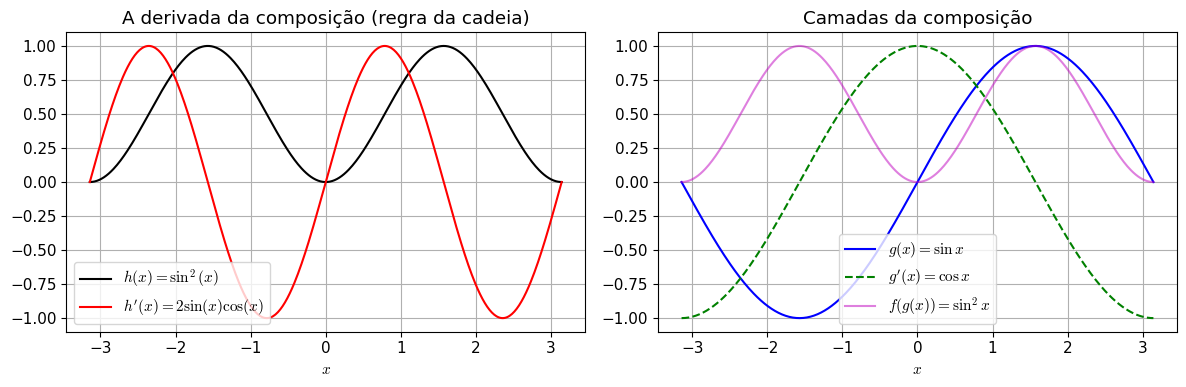

Em ML: a derivada mede a SENSIBILIDADE do resultado a cada parâmetro.
Quanto maior |h'|, mais a saída reage a uma mudança na entrada.


In [3]:
# Regra da cadeia: h(x) = f(g(x)), com f(u)=u^2 e g(x)=sen(x)
# h'(x) = f'(g(x)) * g'(x) = 2 sen(x) * cos(x)
f  = lambda u: u**2
g  = lambda x: np.sin(x)
fp = lambda u: 2*u
gp = lambda x: np.cos(x)
h  = lambda x: f(g(x))
hp = lambda x: fp(g(x)) * gp(x)

xs = np.linspace(-np.pi, np.pi, 400)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(xs, h(xs),  "k-", label="$h(x)=\\sin^2(x)$")
axes[0].plot(xs, hp(xs), "r-", label="$h'(x)=2\\sin(x)\\cos(x)$")
axes[0].legend()
axes[0].set_title("A derivada da composição (regra da cadeia)")
axes[0].set_xlabel("$x$")

axes[1].plot(xs, g(xs),  "b-",  label="$g(x)=\\sin x$")
axes[1].plot(xs, gp(xs), "g--", label="$g'(x)=\\cos x$")
axes[1].plot(xs, f(g(xs)), "m-", alpha=0.5, label="$f(g(x))=\\sin^2 x$")
axes[1].legend()
axes[1].set_title("Camadas da composição")
axes[1].set_xlabel("$x$")
plt.tight_layout()
plt.show()

# Derivada como sensibilidade: onde h' é grande, h muda muito por unidade de x
print("Em ML: a derivada mede a SENSIBILIDADE do resultado a cada parâmetro.")
print("Quanto maior |h'|, mais a saída reage a uma mudança na entrada.")

## 1.3 — Regressão linear com uma variável: modelo e custo MSE

**Modelo:** queremos uma reta que preveja $y$ a partir de $x$:

$$
h(x) = w_0 + w_1 x
$$

**Custo (MSE):** mede o erro total do modelo — a média dos erros ao quadrado:

$$
J(w_0, w_1) = \frac{1}{2m}\sum_{i=1}^{m}\big(h(x_i) - y_i\big)^2
$$

(o fator $\tfrac{1}{2}$ só serve para simplificar a derivada depois).

$J$ é uma função de **duas variáveis** ($w_0$ e $w_1$), e o gráfico dela é uma **superfície em 3D** com formato de tigela (paraboloide). Treinar o modelo = encontrar o **fundo da tigela**, o ponto $(w_0^*, w_1^*)$ onde o erro é mínimo.

> Nota para a aula: a função "perda" do perceptron e a *hinge loss* da SVM desempenham o mesmo papel que o MSE aqui — quantificar o quanto o modelo está errado. O que muda é a fórmula.

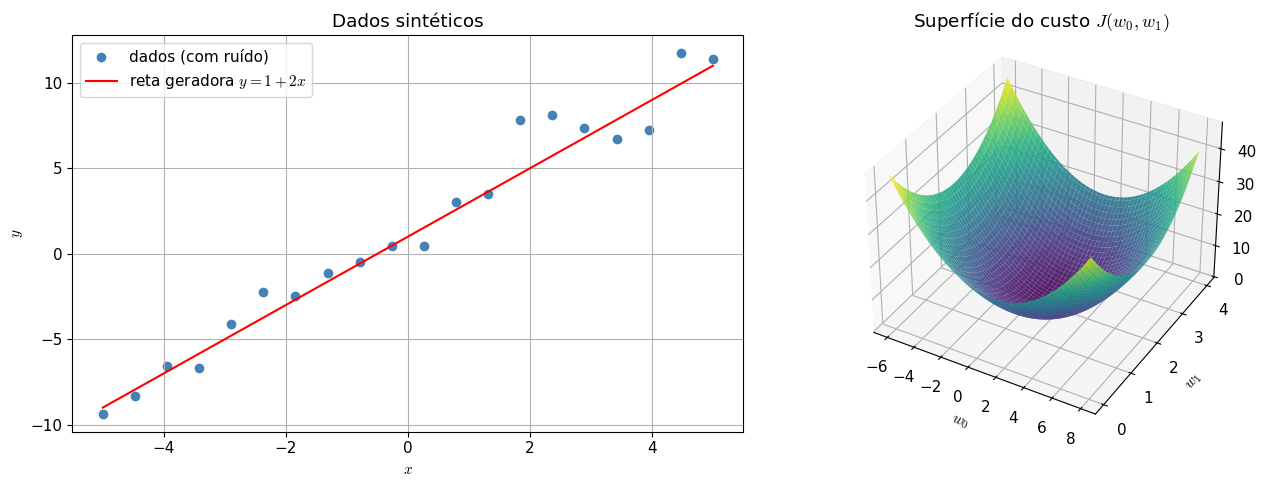

J(1.0, 2.0) = 0.7218  (perto do fundo da tigela)
J(0, 0)            = 21.0313  (uma reta ruim tem custo alto)


In [7]:
# Dados sintéticos para regressão linear.
# x centralizado em [-5, 5] (média 0): deixa a "tigela" bem condicionada e
# o gradiente converge rápido — antecipa a lição "dados não normalizados".
xs = np.linspace(-5, 5, 20)
true_w0, true_w1 = 1.0, 2.0                      # reta "verdadeira" y = 1 + 2x
ys = true_w0 + true_w1 * xs + rng.normal(0, 1.5, size=len(xs))

def custo(w0, w1, x, y):
    m = len(x)
    return np.sum((w0 + w1*x - y)**2) / (2*m)

# Malha para desenhar a superfície de J
W0 = np.linspace(-6, 8, 100)
W1 = np.linspace(0, 4, 100)
W0g, W1g = np.meshgrid(W0, W1)
J = np.array([[custo(w0, w1, xs, ys) for w0 in W0] for w1 in W1])

fig = plt.figure(figsize=(14, 5))
ax = fig.add_subplot(1, 2, 1)
ax.scatter(xs, ys, c="steelblue", label="dados (com ruído)")
ax.plot(xs, true_w0 + true_w1*xs, "r-", label="reta geradora $y=1+2x$")
ax.legend()
ax.set_title("Dados sintéticos")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")

ax = fig.add_subplot(1, 2, 2, projection="3d")
ax.plot_surface(W0g, W1g, J, cmap="viridis", alpha=0.9)
ax.set_title("Superfície do custo $J(w_0, w_1)$")
ax.set_xlabel("$w_0$")
ax.set_ylabel("$w_1$")
ax.set_zlabel("$J$")
ax.view_init(elev=35, azim=-60)
plt.tight_layout()
plt.show()

print(f"J({true_w0}, {true_w1}) = {custo(true_w0, true_w1, xs, ys):.4f}  (perto do fundo da tigela)")
print(f"J(0, 0)            = {custo(0, 0, xs, ys):.4f}  (uma reta ruim tem custo alto)")

## 1.4 — Derivadas parciais, gradiente e a direção de descida

Quando $J$ tem **duas ou mais variáveis**, derivamos uma por vez, tratando as outras como constantes. Isso é a **derivada parcial**:

$$
\frac{\partial J}{\partial w_0}, \qquad \frac{\partial J}{\partial w_1}
$$

Para o custo MSE, usando a regra da cadeia em cada termo:

$$
\frac{\partial J}{\partial w_0} = \frac{1}{m}\sum_{i=1}^{m}\big(h(x_i)-y_i\big), \qquad
\frac{\partial J}{\partial w_1} = \frac{1}{m}\sum_{i=1}^{m}\big(h(x_i)-y_i\big)\, x_i
$$

O **gradiente** é o vetor que junta todas as parciais:

$$
\nabla J = \begin{bmatrix} \frac{\partial J}{\partial w_0} \\[6pt] \frac{\partial J}{\partial w_1} \end{bmatrix}
$$

Interpretação geométrica: $\nabla J$ aponta para a direção de **subida mais íngreme** da tigela; logo, $-\nabla J$ aponta para a **descida mais íngreme**. Essa é a bússola do treinamento.

Na célula abaixo verificamos o gradiente analítico contra **diferenças finitas** (aproximação numérica da derivada) e desenhamos o campo $-\nabla J$ sobre as curvas de nível.

gradiente analítico : [ 0.17409469 -9.74177926]
diferenças finitas  : [ 0.17409469 -9.74177926]


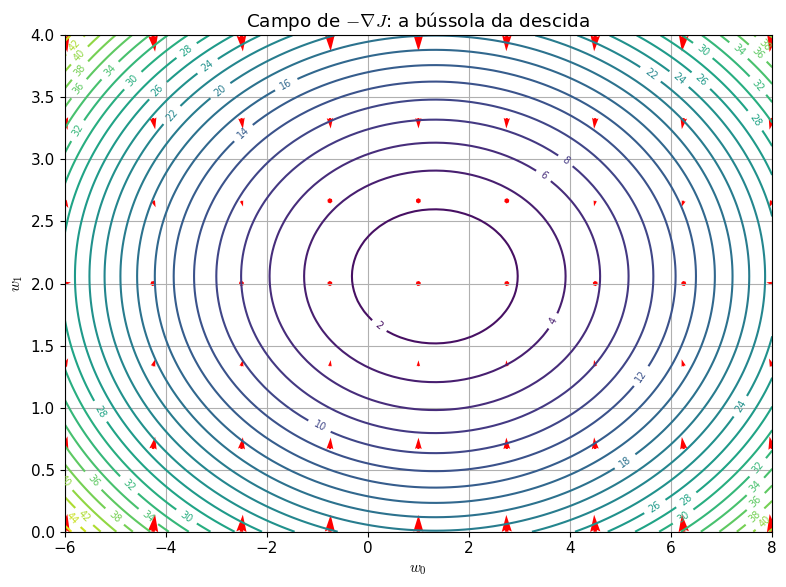

In [8]:
def grad_custo(w0, w1, x, y):
    """Gradiente analítico de J(w0, w1) = (1/2m) Σ (w0 + w1 x - y)^2."""
    m = len(x)
    e = w0 + w1*x - y                     # erros (resíduos)
    return np.array([e.sum()/m, (e*x).sum()/m])

# Verificação por diferenças finitas: (f(x+eps) - f(x-eps)) / (2 eps)
w0, w1 = 1.5, 1.0
g = grad_custo(w0, w1, xs, ys)
eps = 1e-5
gn = np.array([
    (custo(w0+eps, w1, xs, ys) - custo(w0-eps, w1, xs, ys)) / (2*eps),
    (custo(w0, w1+eps, xs, ys) - custo(w0, w1-eps, xs, ys)) / (2*eps),
])
print("gradiente analítico :", g)
print("diferenças finitas  :", gn)

# Campo de -grad J sobre as curvas de nível
fig, ax = plt.subplots(figsize=(8, 6))
cs = ax.contour(W0g, W1g, J, levels=25, cmap="viridis")
ax.clabel(cs, inline=True, fontsize=7)
W0s = np.linspace(-6, 8, 9)
W1s = np.linspace(0, 4, 7)
U = np.zeros((len(W1s), len(W0s)))
V = np.zeros_like(U)
for j, a in enumerate(W1s):
    for i, b in enumerate(W0s):
        gv = grad_custo(b, a, xs, ys)
        U[j, i], V[j, i] = -gv            # -∇J = direção de descida
ax.quiver(W0s, W1s, U, V, color="red", angles="xy", scale=800)
ax.set_title("Campo de $-\\nabla J$: a bússola da descida")
ax.set_xlabel("$w_0$")
ax.set_ylabel("$w_1$")
plt.tight_layout()
plt.show()

## 1.5 — Gradient Descent em lote

Com o gradiente em mãos, o algoritmo é simples: ande um pouco na direção oposta, repita:

$$
w \leftarrow w - \alpha\,\nabla J(w)
$$

- $\alpha$ é a **taxa de aprendizado** (tamanho do passo).
- Em **lote** (*batch*): cada passo usa **todas** as $m$ amostras no gradiente.
- $\alpha$ muito grande → o passo pula por cima do mínimo (diverge); $\alpha$ muito pequeno → demora demais (converge devagar). A célula abaixo compara três valores de $\alpha$.

Uma **época** = uma passagem completa pelo dataset. Em GD em lote, 1 época = 1 atualização de pesos.

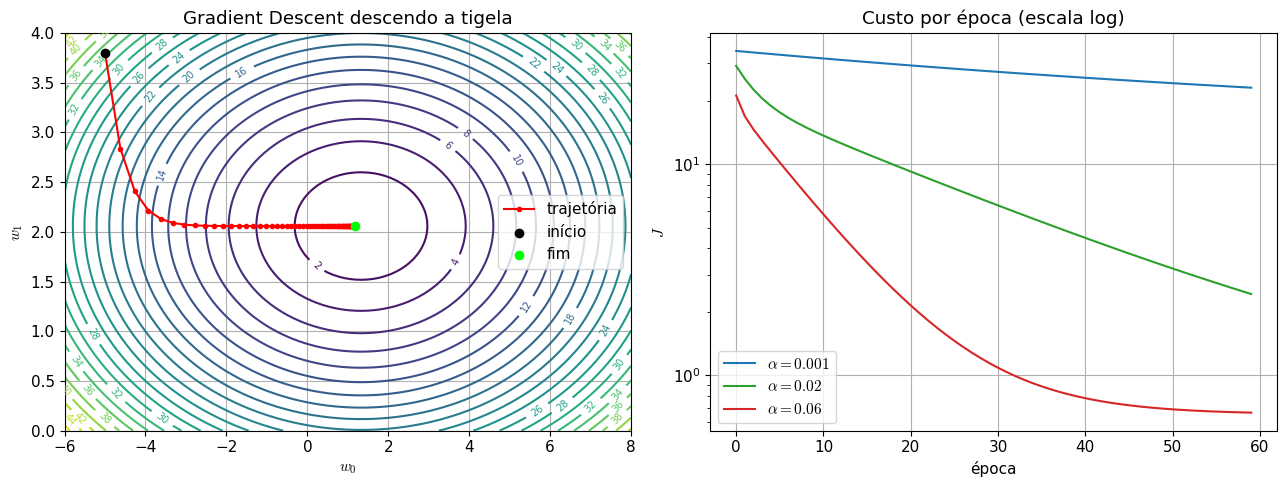

pesos finais: [1.171 2.058]   (geradores verdadeiros: 1.0, 2.0)
moral: alpha muito pequeno é lento; alpha grande demais pode divergir.


In [9]:
def gd_batch(x, y, w0=3.0, w1=3.0, alpha=0.02, epochs=100):
    """Gradient Descent em lote para regressão linear."""
    w = np.array([w0, w1], dtype=float)
    caminho, custos = [w.copy()], []
    for _ in range(epochs):
        w = w - alpha * grad_custo(w[0], w[1], x, y)
        caminho.append(w.copy())
        custos.append(custo(w[0], w[1], x, y))
    return np.array(caminho), np.array(custos)

caminho, custos = gd_batch(xs, ys, w0=-5.0, w1=3.8, alpha=0.06, epochs=60)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cs = axes[0].contour(W0g, W1g, J, levels=25, cmap="viridis")
axes[0].clabel(cs, inline=True, fontsize=7)
axes[0].plot(caminho[:, 0], caminho[:, 1], "r-o", ms=3, label="trajetória")
axes[0].scatter(*caminho[0], color="k", zorder=5, label="início")
axes[0].scatter(*caminho[-1], color="lime", zorder=5, label="fim")
axes[0].legend()
axes[0].set_title("Gradient Descent descendo a tigela")
axes[0].set_xlabel("$w_0$")
axes[0].set_ylabel("$w_1$")

for alpha, cor in [(0.001, "tab:blue"), (0.02, "tab:green"), (0.06, "tab:red")]:
    _, cs_ = gd_batch(xs, ys, w0=-5.0, w1=3.8, alpha=alpha, epochs=60)
    axes[1].plot(cs_, color=cor, label=f"$\\alpha={alpha}$")
axes[1].set_yscale("log")
axes[1].legend()
axes[1].set_title("Custo por época (escala log)")
axes[1].set_xlabel("época")
axes[1].set_ylabel("$J$")
plt.tight_layout()
plt.show()

print("pesos finais:", np.round(caminho[-1], 3), "  (geradores verdadeiros: 1.0, 2.0)")
print("moral: alpha muito pequeno é lento; alpha grande demais pode divergir.")

## 1.6 — Álgebra linear mínima: vetores, normas e produto escalar

Um **vetor** $x = (x_1, x_2, \dots, x_d)$ é uma lista de $d$ números (uma amostra com $d$ features). Operações básicas:

- **Soma** e **produto por escalar**: feitas entrada por entrada.
- **Norma** $\|x\|$ = comprimento do vetor (Pitágoras generalizado):

$$
\|x\| = \sqrt{x_1^2 + x_2^2 + \dots + x_d^2}
$$

- **Produto interno (escalar)**:

$$
w \cdot x = w_1 x_1 + w_2 x_2 + \dots + w_d x_d = \|w\|\,\|x\|\cos\theta
$$

onde $\theta$ é o ângulo entre $w$ e $x$. O cosseno mede a **similaridade**: $+1$ mesma direção, $0$ perpendiculares, $-1$ opostas.

**A ponte para o modelo linear:** a previsão $\hat y = w \cdot x + b$ é um produto interno + um deslocamento $b$ (o viés). No código da aula, $w$ é o vetor `theta` e $b$ é o escalar `theta_0`.

In [10]:
# Produto interno, norma e similaridade de cosseno
u = np.array([3.0, 4.0])
v = np.array([1.0, 2.0])
dot = u @ v
norm_u, norm_v = np.linalg.norm(u), np.linalg.norm(v)
cos = dot / (norm_u * norm_v)

print(f"u·v = {dot}")
print(f"||u|| = {norm_u},  ||v|| = {norm_v:.3f}")
print(f"cos(u, v) = {cos:.3f}   (1 = mesma direção, 0 = perpendicular, -1 = opostas)")

# O modelo linear h(x) = w·x + b é um produto interno:
w = np.array([2.0, -1.0])
b = 0.5
x = np.array([1.5, 2.5])
print(f"h(x) = w·x + b = {w @ x + b}")

# Similaridade de cosseno entre "palavras" (vetores Bag-of-Words simplificados)
doc1 = np.array([3, 1, 0, 4])   # documento 1 (contagens de 4 palavras)
doc2 = np.array([2, 2, 0, 5])   # documento 2
print(f"similaridade(doc1, doc2) = {doc1 @ doc2 / (np.linalg.norm(doc1)*np.linalg.norm(doc2)):.3f}")

u·v = 11.0
||u|| = 5.0,  ||v|| = 2.236
cos(u, v) = 0.984   (1 = mesma direção, 0 = perpendicular, -1 = opostas)
h(x) = w·x + b = 1.0
similaridade(doc1, doc2) = 0.956


## 1.7 — Matrizes e a forma vetorizada $X w$

Empilhe as $m$ amostras como **linhas** de uma matriz $X$ (chamada *matriz de design*), de tamanho $m \times d$:

$$
X = \begin{bmatrix} —\; x^{(1)}\; — \\ —\; x^{(2)}\; — \\ \vdots \\ —\; x^{(m)}\; — \end{bmatrix}
\qquad \Rightarrow \qquad
X w = \begin{bmatrix} x^{(1)}\cdot w \\ x^{(2)}\cdot w \\ \vdots \\ x^{(m)}\cdot w \end{bmatrix}
$$

**Uma única multiplicação matriz-vetor calcula as $m$ previsões de uma vez.** Em Python, `X @ w` (ou `np.dot(X, w)`) delega o trabalho a bibliotecas nativas ultra-otimizadas (**BLAS** — Basic Linear Algebra Subprograms: código em C/Fortran com instruções SIMD, uso inteligente de cache e múltiplos núcleos). O laço `for` em Python, por outro lado, paga o custo do interpretador a cada iteração e aloca objetos a cada passo — por isso é dezenas a centenas de vezes mais lento.

> **Nota (para não confundir siglas):** **SVD** (Decomposição em Valores Singulares) é uma fatoração de matrizes usada em PCA e em sistemas de recomendação — assunto de outras aulas. Nesta aula, o protagonista é a **SVM** (Support Vector Machine), e o que precisamos de matrizes é apenas o produto $X w$.

laço Python : 0.0410s
X @ w (BLAS): 0.003899s   (speedup ~11x)
resultados iguais? True


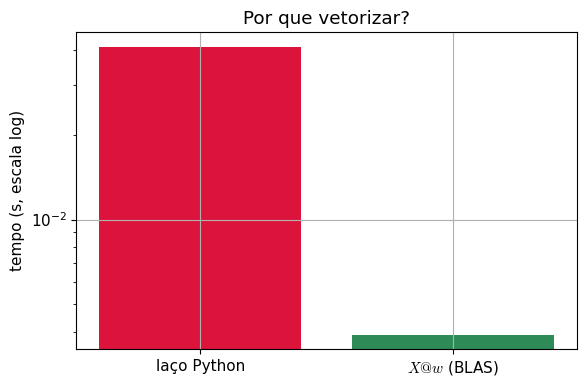

In [12]:
# Laço Python x vetorização (BLAS)
m, d = 5000, 1000
X_mat = rng.normal(size=(m, d))
w = rng.normal(size=d)

_ = X_mat @ w                    # aquecimento: 1ª chamada paga a inicialização do BLAS

t0 = time.perf_counter()
scores_loop = np.array([np.sum(X_mat[i] * w) for i in range(m)])
t_loop = time.perf_counter() - t0

t0 = time.perf_counter()
scores_vec = X_mat @ w           # uma chamada BLAS
t_vec = time.perf_counter() - t0

print(f"laço Python : {t_loop:.4f}s")
print(f"X @ w (BLAS): {t_vec:.6f}s   (speedup ~{t_loop/t_vec:.0f}x)")
print("resultados iguais?", np.allclose(scores_loop, scores_vec))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["laço Python", "$X @ w$ (BLAS)"], [t_loop, t_vec],
       color=["crimson", "seagreen"])
ax.set_yscale("log")
ax.set_ylabel("tempo (s, escala log)")
ax.set_title("Por que vetorizar?")
plt.tight_layout()
plt.show()

## 1.8 — Classificador linear, hiperplanos e margem (funcional e geométrica)

### O classificador linear

No lugar de prever um número, a classificação usa o **score** e o **sinal**:

$$
s(\mathbf{x}) = \mathbf{w}\cdot\mathbf{x} + b, \qquad \hat y = \operatorname{sign}(s(\mathbf{x}))
$$

A **fronteira de decisão** é o conjunto onde o score zera:

$$
\mathbf{w}\cdot\mathbf{x} + b = 0
$$

Em 2D é uma reta; em $d$ dimensões, um **hiperplano** (uma "superfície plana" de dimensão $d-1$). O vetor $\mathbf{w}$ é **perpendicular** (normal) à fronteira e aponta para o lado positivo: caminhando na direção de $\mathbf{w}$, o score $s(\mathbf{x})$ cresce.

### A margem funcional: um número que diz se o ponto está certo

Com rótulos $y_i \in \{-1, +1\}$, multiplique o rótulo pelo score:

$$
z_i = y_i\,(\mathbf{w}\cdot\mathbf{x}_i + b)
$$

- $z_i > 0$ → ponto **correto** (o score e o rótulo "concordam");
- $z_i \le 0$ → ponto **errado**.

Esse produto $z_i$ é a **margem funcional** — "funcional" porque depende da escala de $\mathbf{w}$: se multiplicarmos $\mathbf{w}$ e $b$ por 2, $z_i$ dobra, mas a reta continua no mesmo lugar. É exatamente a expressão que aparece dentro do `if` do perceptron e da SVM da aula.

### O que falta: a distância REAL até a fronteira (margem geométrica)

A margem funcional responde "está certo?", mas não "a que distância da fronteira?". A **margem geométrica** responde a segunda pergunta — e é ela que a SVM vai querer maximizar. A célula seguinte deriva a fórmula passo a passo, sem pressa.

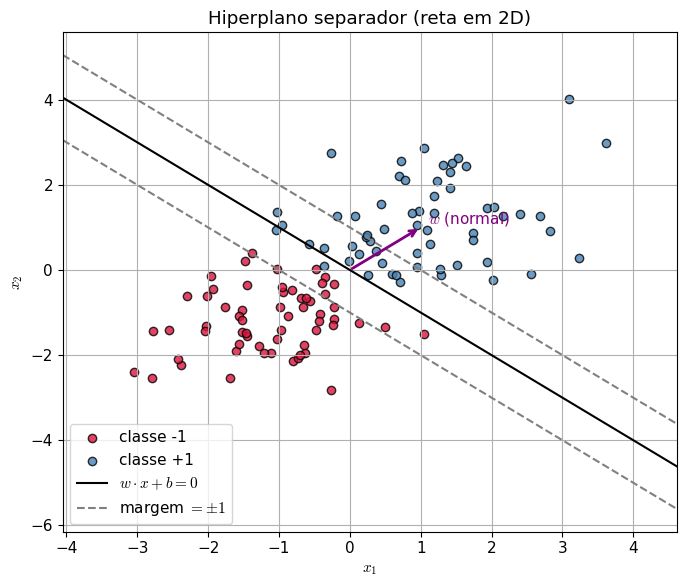

distância de [1.  1.5] ao hiperplano = 1.768


In [20]:
# Classificador linear: s(x) = w·x + b ; fronteira s = 0 ; margem |s|/||w||
w = np.array([1.0, 1.0])
b = 0.0

fig, ax = plt.subplots(figsize=(7, 6))
plot_dados(ax, X_2d, y_2d, titulo="Hiperplano separador (reta em 2D)")

xmin, xmax = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
plot_reta(ax, w, b, xmin, xmax, cor="black", rotulo="$w\\cdot x + b = 0$")
plot_reta(ax, w, b - 1, xmin, xmax, cor="gray", ls="--", rotulo="margem $=\\pm 1$")
plot_reta(ax, w, b + 1, xmin, xmax, cor="gray", ls="--")

# A normal w aponta para o lado positivo
meio = np.array([0.0, -b / w[1]])
ax.annotate("", xy=meio + w, xytext=meio,
            arrowprops=dict(arrowstyle="->", color="purple", lw=2))
ax.text(*(meio + w * 1.1), "$w$ (normal)", color="purple")
ax.set_xlim(xmin, xmax)
ax.legend()
plt.tight_layout()
plt.show()

p = np.array([1.0, 1.5])
print(f"distância de {p} ao hiperplano = {abs(w @ p + b) / np.linalg.norm(w):.3f}")

### Derivando a margem geométrica (mini-aula passo a passo)

Queremos a distância $d_i$ do ponto $\mathbf{x}_i$ até o hiperplano $\mathbf{w}\cdot\mathbf{x}+b=0$.

**Passo 1 — a distância vive na direção da normal.** Como $\mathbf{w}$ é perpendicular ao hiperplano, a distância de um ponto até ele é o comprimento da projeção do ponto na direção da **normal unitária** $\hat{\mathbf{w}} = \mathbf{w}/\|\mathbf{w}\|$ (dividir pela norma transforma $\mathbf{w}$ em um vetor de comprimento 1, que serve de "régua").

**Passo 2 — o truque do ponto de referência.** Pegue um ponto qualquer $\mathbf{x}_0$ que esteja SOBRE o hiperplano (portanto $\mathbf{w}\cdot\mathbf{x}_0 + b = 0$). O vetor que liga $\mathbf{x}_0$ a $\mathbf{x}_i$ é $\mathbf{x}_i - \mathbf{x}_0$. Projetando esse vetor na normal unitária, obtemos a distância com sinal:

$$
d_i = \hat{\mathbf{w}}\cdot(\mathbf{x}_i - \mathbf{x}_0)
    = \frac{\mathbf{w}\cdot\mathbf{x}_i - \mathbf{w}\cdot\mathbf{x}_0}{\|\mathbf{w}\|}
$$

**Passo 3 — use a equação do hiperplano.** Como $\mathbf{x}_0$ está na fronteira, $\mathbf{w}\cdot\mathbf{x}_0 = -b$. Substituindo:

$$
d_i = \frac{\mathbf{w}\cdot\mathbf{x}_i + b}{\|\mathbf{w}\|}
$$

**Passo 4 — inclua o rótulo para medir "do lado certo".** Multiplicando por $y_i$:

$$
\gamma_i = y_i\,\frac{\mathbf{w}\cdot\mathbf{x}_i + b}{\|\mathbf{w}\|}
$$

$\gamma_i$ é a **margem geométrica** da amostra $i$: se o ponto está correto, $\gamma_i > 0$ e vale a distância até a fronteira; se está errado, $\gamma_i < 0$ e mede o "quanto para trás" ele está. Ao contrário da margem funcional, a margem geométrica **não depende da escala de $\mathbf{w}$** — é uma distância de verdade, em "metros".

> **Resumo:** margem funcional $y_i(\mathbf{w}\cdot\mathbf{x}_i+b)$ diz *se* o ponto está certo; margem geométrica $y_i(\mathbf{w}\cdot\mathbf{x}_i+b)/\|\mathbf{w}\|$ diz *a que distância* ele está da fronteira.

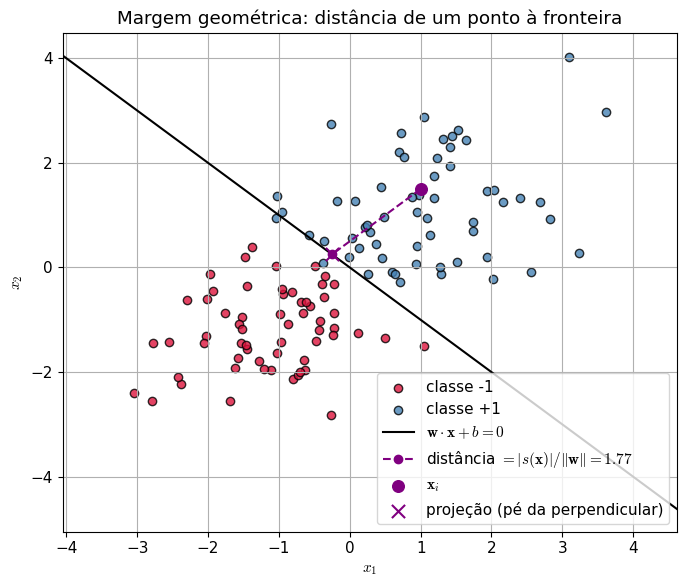

score s(x)  = 2.50
distância   = |s|/||w|| = 1.77


In [28]:
# Visualizando a margem geométrica: distância = projeção na normal
w = np.array([1.0, 1.0])
b = 0.0
p = np.array([1.0, 1.5])                  # ponto de interesse

d_signed = (w @ p + b) / np.linalg.norm(w)                 # distância com sinal
pe = p - d_signed * (w / np.linalg.norm(w))                # pé da perpendicular

fig, ax = plt.subplots(figsize=(7, 6))
plot_dados(ax, X_2d, y_2d, titulo="Margem geométrica: distância de um ponto à fronteira")
xmin, xmax = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
plot_reta(ax, w, b, xmin, xmax, cor="black", rotulo="$\\mathbf{w}\\cdot\\mathbf{x}+b=0$")
ax.plot([p[0], pe[0]], [p[1], pe[1]], "o--", color="purple",
        label=f"distância $= |s(\\mathbf{{x}})|/\\|\\mathbf{{w}}\\| = {abs(d_signed):.2f}$")
ax.scatter(*p, color="purple", s=70, zorder=5, label="$\\mathbf{x}_i$")
ax.scatter(*pe, color="purple", marker="x", s=90, zorder=5, label="projeção (pé da perpendicular)")
ax.set_xlim(xmin, xmax)
ax.legend()
plt.tight_layout()
plt.show()

print(f"score s(x)  = {w @ p + b:.2f}")
print(f"distância   = |s|/||w|| = {abs(d_signed):.2f}")

## 1.9 — Perceptron: atualização, convergência e limitações

O **perceptron** (Rosenblatt, 1958) treina apenas com os erros:

$$
\text{se } y_i\,(w\cdot x_i + b) \le 0: \qquad w \leftarrow w + y_i\, x_i, \quad b \leftarrow b + y_i
$$

**Por que isso funciona?** Se o ponto $x_i$ é classe $+1$ e foi classificado como $-1$, somar $y_i x_i = x_i$ a $w$ aumenta o score $w \cdot x_i$, empurrando a fronteira na direção de corrigir esse ponto. Para $y_i = -1$ subtraímos.

**Propriedades:**
- Se os dados são **linearmente separáveis**, o perceptron converge para *alguma* reta separadora (em finitas atualizações — teorema de convergência de Novikoff).
- Ele **não otimiza a margem**: qualquer reta que separe serve, mesmo que passe "raspando" nos pontos. Por isso generaliza pior — é a motivação da SVM.
- Em dados **não linearmente separáveis** (ex.: XOR), ele nunca para de errar.

O laço do código antigo da aula era exatamente esse algoritmo — e `T=20` já significava épocas nele.

épocas até separar: 4


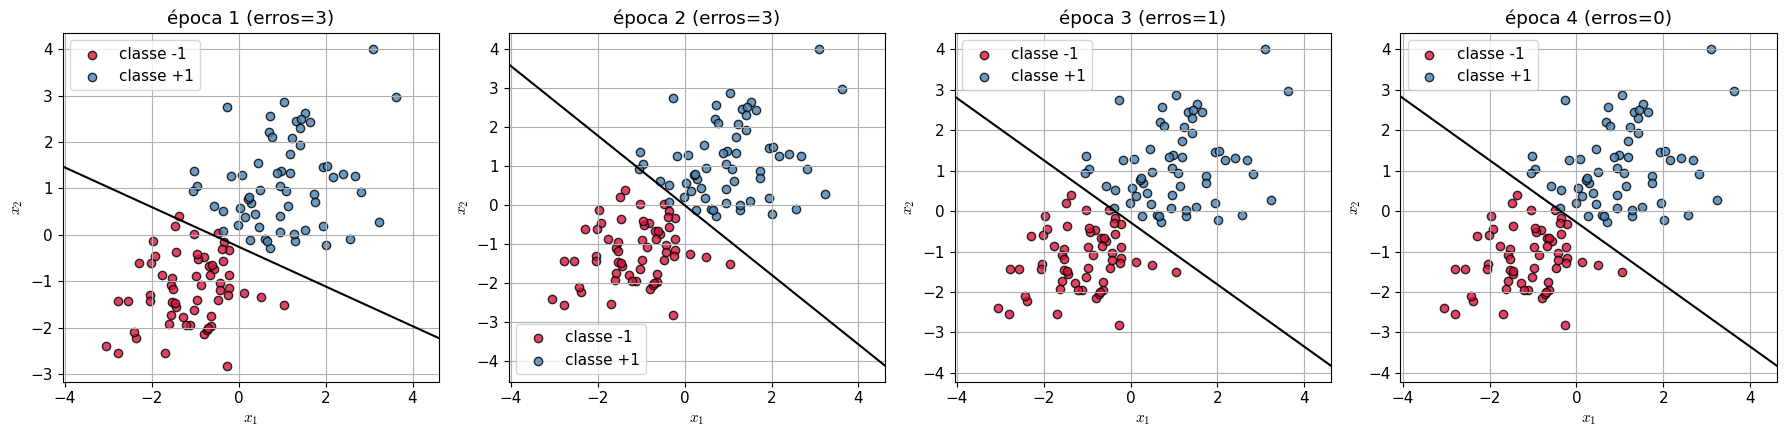

In [16]:
def perceptron(X, y, epochs=20, seed=42):
    """Perceptron clássico: atualiza só quando erra."""
    rng_p = np.random.default_rng(seed)
    d = X.shape[1]
    w = np.zeros(d)
    b = 0.0
    frames = []
    for ep in range(epochs):
        erros = 0
        for i in rng_p.permutation(len(X)):
            if y[i] * (w @ X[i] + b) <= 0:   # errou?
                w = w + y[i] * X[i]          # empurra a fronteira
                b = b + y[i]
                erros += 1
        frames.append((w.copy(), b, erros))
        if erros == 0:
            break
    return w, b, frames

w_p, b_p, frames = perceptron(X_2d, y_2d, epochs=20)
print(f"épocas até separar: {len(frames)}")

# Mostra 4 momentos igualmente espaçados do treinamento
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
xmin, xmax = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
indices = np.linspace(0, len(frames) - 1, 4).astype(int)
for ax, idx in zip(axes, indices):
    w, b, erros = frames[idx]
    plot_dados(ax, X_2d, y_2d, titulo=f"época {idx+1} (erros={erros})")
    plot_reta(ax, w, b, xmin, xmax, cor="black")
    ax.set_xlim(xmin, xmax)
plt.tight_layout()
plt.show()

erros na última época: 4 -> nunca zera: dado não linearmente separável


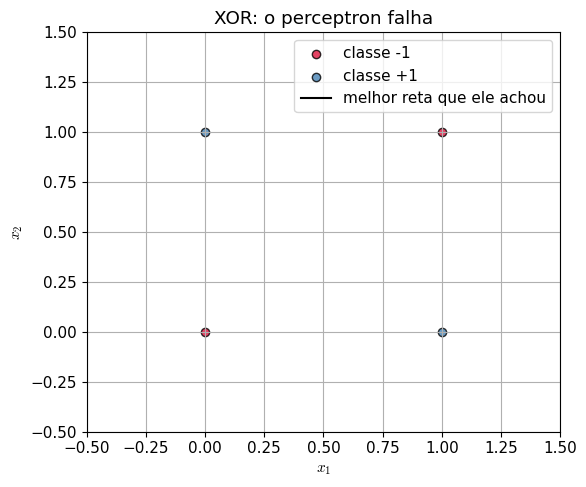

In [17]:
# XOR: NENHUMA reta separa as classes -> o perceptron nunca converge
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([-1, 1, 1, -1])
w_x, b_x, fr = perceptron(X_xor, y_xor, epochs=50)
print("erros na última época:", fr[-1][2], "-> nunca zera: dado não linearmente separável")

fig, ax = plt.subplots(figsize=(6, 5))
plot_dados(ax, X_xor, y_xor, titulo="XOR: o perceptron falha")
plot_reta(ax, w_x, b_x, -0.5, 1.5, cor="black", rotulo="melhor reta que ele achou")
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.legend()
plt.tight_layout()
plt.show()

## 1.10 — SGD e mini-batch Gradient Descent

Três variantes do mesmo algoritmo $w \leftarrow w - \alpha \nabla J$:

| Variante | Gradiente usa | Atualizações por época | Característica |
|---|---|---|---|
| **Batch GD** | todas as $m$ amostras | 1 | preciso, porém caro |
| **SGD** | 1 amostra aleatória | $m$ | barato e **ruidoso** |
| **Mini-batch** | $b$ amostras | $m/b$ | equilíbrio |

**SGD** (Stochastic Gradient Descent): cada passo usa só uma amostra, então é barato e pode ser aplicado a datasets enormes (por isso é o padrão da indústria). A trajetória é ruidosa, mas em média aponta para baixo — o ruído até ajuda a escapar de mínimos locais ruins.

**Vocabulário (essencial para ler o código da aula):**

- **iteração** = uma atualização de pesos;
- **época** = uma passada completa pelo dataset ($m$ iterações no SGD);
- **batch size** = quantas amostras por atualização (1 = SGD puro; $m$ = batch; meio-termo = mini-batch).

> ⚠️ Foi a **confusão entre iteração e época** que gerou a chamada `SGD(..., 50000000, ...)` no código antigo — 50 milhões de *iterações*, o equivalente a ~12.500 *épocas*.

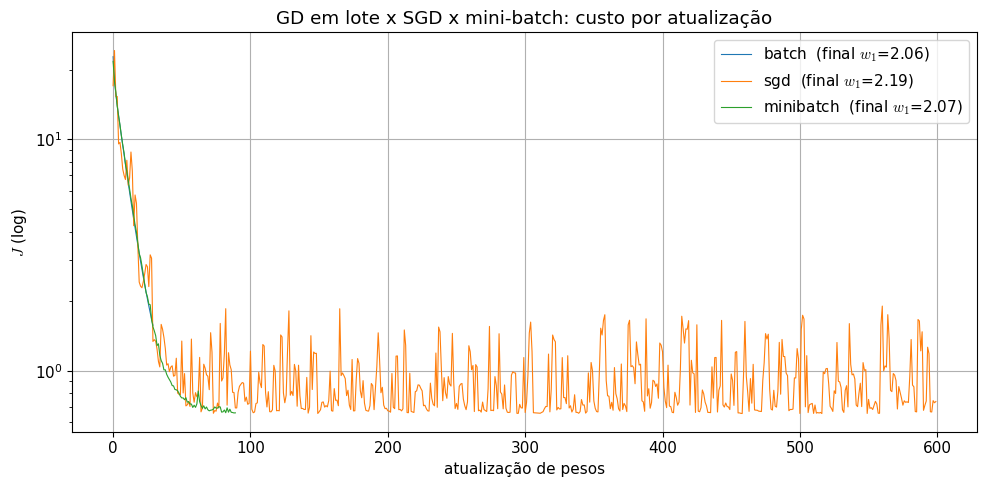

O SGD chega rápido, mas por um caminho ruidoso. Em média, desce.


In [21]:
def grad_amostra(w, x_i, y_i):
    e = w[0] + w[1]*x_i - y_i
    return np.array([e, e*x_i])

def treinar(x, y, modo="batch", alpha=0.05, epochs=30, batch_size=8):
    rng2 = np.random.default_rng(0)
    w = np.array([-5.0, 3.8], dtype=float)
    custos = []
    m = len(x)
    for _ in range(epochs):
        perm = rng2.permutation(m)
        if modo == "batch":
            w = w - alpha * grad_custo(w[0], w[1], x, y)
            custos.append(custo(w[0], w[1], x, y))
        elif modo == "sgd":
            for i in perm:
                w = w - alpha * grad_amostra(w, x[i], y[i])
                custos.append(custo(w[0], w[1], x, y))
        else:                                   # mini-batch
            for s in range(0, m, batch_size):
                idx = perm[s:s+batch_size]
                g = np.mean([grad_amostra(w, x[i], y[i]) for i in idx], axis=0)
                w = w - alpha * g
                custos.append(custo(w[0], w[1], x, y))
    return np.array(custos), w

fig, ax = plt.subplots(figsize=(10, 5))
for modo, cor in [("batch", "tab:blue"), ("sgd", "tab:orange"), ("minibatch", "tab:green")]:
    cs, wf = treinar(xs, ys, modo=modo)
    ax.plot(cs, lw=0.8, color=cor, label=f"{modo}  (final $w_1$={wf[1]:.2f})")
ax.set_yscale("log")
ax.set_ylabel("$J$ (log)")
ax.set_xlabel("atualização de pesos")
ax.set_title("GD em lote x SGD x mini-batch: custo por atualização")
ax.legend()
plt.tight_layout()
plt.show()
print("O SGD chega rápido, mas por um caminho ruidoso. Em média, desce.")

## 1.11 — SVM linear: a aula completa (motivação, objetivo, subgradiente e vetores de suporte)

### 11.1 A motivação: o defeito do perceptron

O perceptron para assim que encontra **qualquer** reta que separe os dados. Mas retas diferentes separam com qualidades diferentes: uma passa "raspando" nos pontos, outra passa bem no meio do corredor entre as classes. Qual generaliza melhor para dados novos? A do meio — porque sobra espaço para o ruído dos dados futuros.

> **A ideia central da SVM:** entre todas as retas que separam os dados, escolher a que fica o mais longe possível dos pontos mais próximos — ou seja, **maximizar a margem**.

### 11.2 Margem rígida (caso ideal: dados perfeitamente separáveis)

Seja $\gamma$ a **menor** margem geométrica entre todos os pontos (o "gargalo" do corredor):

$$
\gamma = \min_i \; y_i\,\frac{\mathbf{w}\cdot\mathbf{x}_i + b}{\|\mathbf{w}\|}
$$

A SVM de **margem rígida** escolhe $\mathbf{w}$ e $b$ para maximizar $\gamma$. Pode-se mostrar (ótimo exercício de otimização, mas fora do escopo aqui) que maximizar $\gamma$ é **equivalente** a:

$$
\min_{\mathbf{w},b} \; \frac{1}{2}\|\mathbf{w}\|^2
\quad \text{sujeito a} \quad
y_i(\mathbf{w}\cdot\mathbf{x}_i + b) \ge 1 \;\; \forall i
$$

Os "1" e "1/2" são apenas convenções de escala — o ponto é a conclusão fundamental:

> **margem grande ⇔ pesos pequenos ($\|\mathbf{w}\|$ pequeno).**

### 11.3 Margem suave (o caso real): a hinge loss

Dados reais têm ruído e outliers; exigir separação perfeita (`∀i`) é impossível. A solução é **permitir violações, cobrando caro por elas**. A multa é a **hinge loss**:

$$
\ell_i = \max(0,\; 1 - y_i(\mathbf{w}\cdot\mathbf{x}_i + b))
$$

Lendo a hinge caso a caso, com $z_i = y_i(\mathbf{w}\cdot\mathbf{x}_i + b)$:

| Situação | $z_i$ | Multa $\ell_i$ |
|---|---|---|
| Correto, fora da margem | $z_i \ge 1$ | $0$ (nada a pagar) |
| Correto, mas dentro da margem | $0 < z_i < 1$ | $1 - z_i$ (pouco) |
| Errado | $z_i \le 0$ | $1 - z_i \ge 1$ (muito, proporcional ao erro) |

### 11.4 A função objetivo completa (a "SGD" da aula)

$$
J(\mathbf{w}, b) = \frac{1}{n}\sum_{i=1}^{n}\max(0,\;1 - y_i(\mathbf{w}\cdot\mathbf{x}_i+b)) \;+\; \frac{\lambda}{2}\,\|\mathbf{w}\|^2
$$

- **1º termo:** média das hinge losses — o erro total do modelo;
- **2º termo:** **regularização L2** $\frac{\lambda}{2}\|\mathbf{w}\|^2$ — puxa $\|\mathbf{w}\|$ para baixo, ou seja, empurra a margem para cima (Seção 11.2) e combate o overfitting;
- **$\lambda$:** o hiperparâmetro de equilíbrio. $\lambda$ grande → prioriza margem grande (modelo simples); $\lambda$ pequeno → prioriza acertar os dados (modelo complexo). *Overfitting* é quando o modelo "decora" o treino: acurácia alta no treino e baixa no teste.

### 11.5 Onde está a derivada? (o subgradiente)

A hinge tem uma **quina** em $z=1$ (à esquerda ela desce, à direita é plana), então a derivada clássica não existe exatamente nesse ponto. Usamos o **subgradiente**: fora da quina é a derivada normal; na quina, qualquer valor entre os dois lados serve. Como a quina é um único ponto, na prática isso não atrapalha. Aplicando a regra da cadeia (Seção 1.4):

- **Caso $z_i \ge 1$** (hinge inativa): só a regularização empurra. Como $\frac{\partial}{\partial \mathbf{w}}\big(\frac{\lambda}{2}\|\mathbf{w}\|^2\big) = \lambda\mathbf{w}$:

$$
\mathbf{w} \leftarrow \mathbf{w} - \eta\,\lambda\mathbf{w} = (1 - \eta\lambda)\,\mathbf{w}
$$

- **Caso $z_i < 1$** (hinge ativa): ela contribui com $-y_i\mathbf{x}_i$ (a derivada de $\max(0,1-z_i)$ em relação a $\mathbf{w}$):

$$
\mathbf{w} \leftarrow \mathbf{w} - \eta\,(\lambda\mathbf{w} - y_i\mathbf{x}_i)
= (1 - \eta\lambda)\,\mathbf{w} + \eta\,y_i\,\mathbf{x}_i,
\qquad
b \leftarrow b + \eta\,y_i
$$

(o viés $b$ não é regularizado — recebe apenas a contribuição da hinge). São **exatamente** os dois ramos do `if margin < 1:` do código da aula, com taxa decrescente $\eta = \eta_0/\sqrt{t}$.

### 11.6 O que são os vetores de suporte

**Vetores de suporte** são os pontos que "seguram" a fronteira no lugar: as amostras com margem funcional $z_i \le 1$ — dentro da margem ou erradas — as únicas com hinge loss $> 0$.

Olhe para o caso $z_i < 1$ da Seção 11.5: é o único caso em que a amostra entra na atualização de $\mathbf{w}$. As demais contribuem com exatamente $0$. Consequências:

- A fronteira é determinada **somente** por esses poucos pontos; os demais podem ser removidos sem mudar nada.
- Remova um vetor de suporte e a fronteira muda.
- É por isso que a SVM é "econômica": ela aprende com um punhado de pontos críticos.

A célula de código abaixo mostra a hinge em ação e, na sequência, treina a SVM destacando exatamente quem são os vetores de suporte.

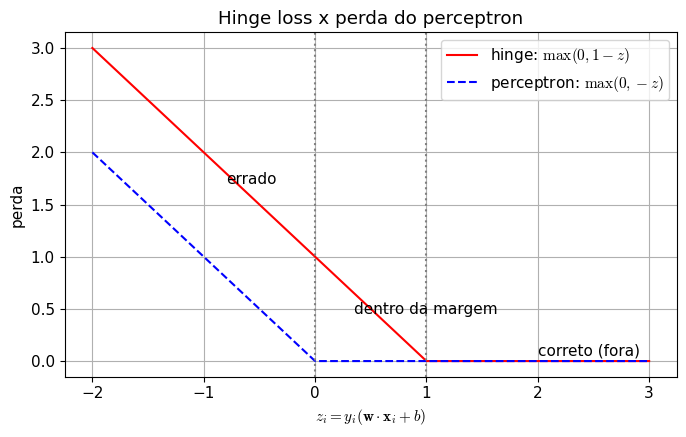

In [29]:
# Hinge loss x perda do perceptron, como função de z_i = y_i (w·x_i + b)
z = np.linspace(-2, 3, 500)
hinge      = np.maximum(0, 1 - z)      # penaliza erros E pontos dentro da margem (z < 1)
perceptron = np.maximum(0, -z)         # só penaliza erros (z <= 0)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(z, hinge, "r-", label="hinge: $\\max(0, 1 - z)$")
ax.plot(z, perceptron, "b--", label="perceptron: $\\max(0, -z)$")
ax.axvline(0, color="gray", ls=":")
ax.axvline(1, color="gray", ls=":")
ax.annotate("errado", xy=(-0.8, 1.7))
ax.annotate("dentro da margem", xy=(0.35, 0.45))
ax.annotate("correto (fora)", xy=(2.0, 0.05))
ax.set_xlabel("$z_i = y_i(\\mathbf{w}\\cdot\\mathbf{x}_i + b)$")
ax.set_ylabel("perda")
ax.set_title("Hinge loss x perda do perceptron")
ax.legend()
plt.tight_layout()
plt.show()

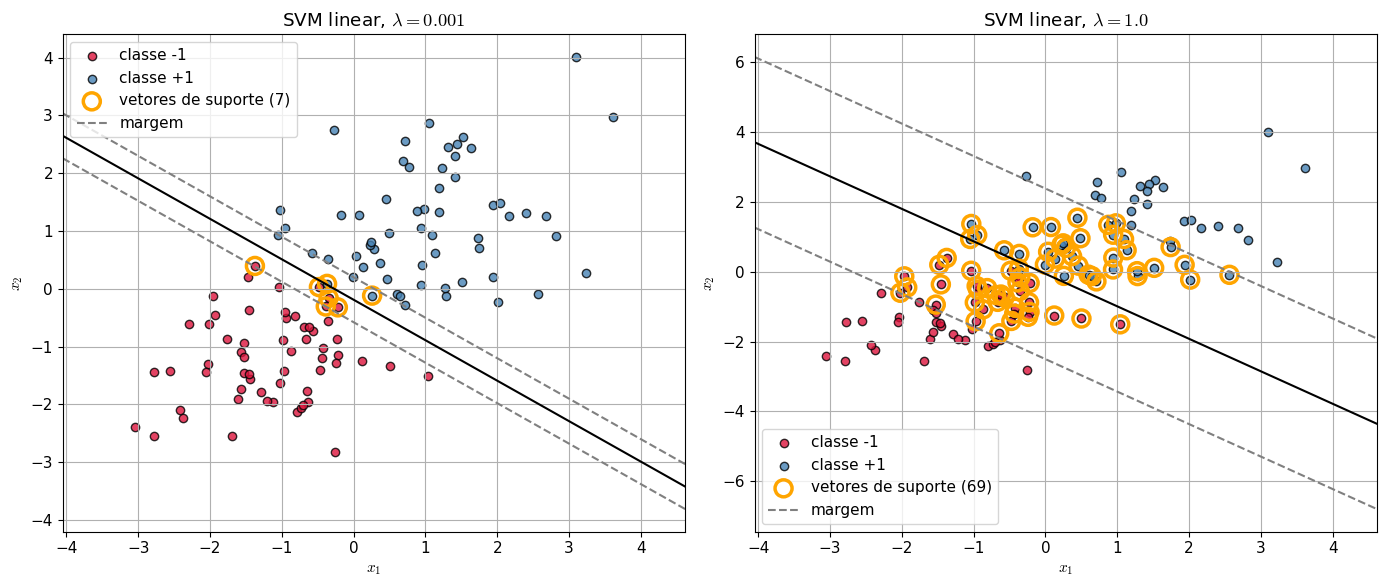

λ pequeno -> menos regularização (margem geométrica menor, ajusta mais aos dados).
λ grande -> pesos pequenos (margem geométrica maior, mas tolera mais erros).
Os pontos circulados em laranja são os vetores de suporte: sem eles, a fronteira mudaria.


In [30]:
def svm_sgd(X, y, epochs=30, eta0=0.5, lam=0.01, seed=42):
    """SVM linear treinada com SGD (mesma matemática da função `SGD` da aula)."""
    rng_s = np.random.default_rng(seed)
    w = np.zeros(X.shape[1])
    b = 0.0
    t = 0
    for _ in range(epochs):
        for i in rng_s.permutation(len(X)):
            t += 1
            eta = eta0 / np.sqrt(t)
            if y[i] * (w @ X[i] + b) < 1:               # hinge ativa
                w = (1 - eta * lam) * w + eta * y[i] * X[i]
                b = b + eta * y[i]
            else:                                       # só regularização
                w = (1 - eta * lam) * w
    return w, b

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
xmin, xmax = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
for ax, lam in zip(axes, [0.001, 1.0]):
    w_s, b_s = svm_sgd(X_2d, y_2d, lam=lam)
    plot_dados(ax, X_2d, y_2d, titulo=f"SVM linear, $\\lambda={lam}$")
    # Vetores de suporte: pontos com margem funcional <= 1 (dentro da
    # margem ou errados) — são os únicos que influenciam a fronteira.
    sv = y_2d * (X_2d @ w_s + b_s) <= 1.0
    ax.scatter(X_2d[sv, 0], X_2d[sv, 1], s=150, facecolors="none",
               edgecolors="orange", linewidths=2.5,
               label=f"vetores de suporte ({sv.sum()})")
    plot_reta(ax, w_s, b_s, xmin, xmax, cor="black")
    plot_reta(ax, w_s, b_s - 1, xmin, xmax, cor="gray", ls="--", rotulo="margem")
    plot_reta(ax, w_s, b_s + 1, xmin, xmax, cor="gray", ls="--")
    ax.set_xlim(xmin, xmax)
    ax.legend()
plt.tight_layout()
plt.show()
print("λ pequeno -> menos regularização (margem geométrica menor, ajusta mais aos dados).")
print("λ grande -> pesos pequenos (margem geométrica maior, mas tolera mais erros).")
print("Os pontos circulados em laranja são os vetores de suporte: sem eles, a fronteira mudaria.")

# 2 — Como o código antigo funcionava

## 2.1 — Anatomia do `Model.py` antigo, função por função

**`PerceptronBase(features, labels, T)`** — já era o perceptron correto:

```python
import random
import numpy as np

def PerceptronBase(features, labels, T):
    theta = np.zeros(features.shape[1])   # pesos
    theta_0 = 0.0                         # viés
    for _ in range(T):                    # T = épocas (aqui, ok)
        for _ in range(len(features)):
            i = random.randint(0, len(features) - 1)      # sorteio COM reposição
            if labels[i] * (np.dot(theta, features[i]) + theta_0) <= 0:
                theta = theta + labels[i] * features[i]
                theta_0 = theta_0 + labels[i]
    return theta, theta_0
```

**`SGD(x, y, T, eta_0, lambda_)`** — a SVM linear (hinge + L2) da teoria:

```python
def SGD(x, y, T, eta_0, lambda_):
    theta = np.zeros(x.shape[1])
    theta_0 = 0.0
    for t in range(1, T + 1):             # T = ITERAÇÕES (o problema!)
        i = random.randint(0, len(x) - 1)
        eta = eta_0 / np.sqrt(t)
        margin = y[i] * (np.dot(theta, x[i]) + theta_0)
        if margin < 1:
            theta = (1 - eta * lambda_) * theta + eta * y[i] * x[i]
            theta_0 = theta_0 + eta * y[i]
        else:
            theta = (1 - eta * lambda_) * theta
    return theta, theta_0
```

**`Acuracia`** — laço Python linha a linha:

```python
def classificar(theta, theta_0, x):
    return 1 if np.dot(theta, x) + theta_0 > 0 else -1

def Acuracia(theta, theta_0, x, y):
    acertos = 0
    for i in range(len(x)):
        if classificar(theta, theta_0, x[i]) == y[i]:
            acertos += 1
    return acertos / len(x)
```

**Suposições escondidas / pontos frágeis:**

1. `T` significa *épocas* em `PerceptronBase` e *iterações* em `SGD` — mesmo nome, duas unidades diferentes.
2. `random.randint` sorteia **com reposição**: numa época, algumas amostras são vistas várias vezes e outras nenhuma.
3. Cada iteração do `SGD` aloca **vetores densos novos** (`(1-ηλ)*theta` e `η*y*x[i]`), e o `np.dot` percorre o vocabulário **inteiro** (matriz densa), mesmo sendo ~99% zeros.
4. `Acuracia` chama `classificar` (que usa `np.dot`) uma vez por linha, em Python puro.

## 2.2 — Anatomia do `BagOfWords.py` e do fluxo principal antigos

**`BagOfWords.py` antigo:**

```python
def create_bow_vectorizer(conjunto_textos):
    conjunto_textos_processados = conjunto_textos.apply(preprocess_text)  # 1ª passada
    vectorizer = CountVectorizer()
    vectorizer.fit(conjunto_textos_processados)
    return vectorizer

def GetFeatures(texts, vectorizer):
    textos_preprocessados = texts.apply(preprocess_text)                  # 2ª passada (redundante!)
    matriz_completa = vectorizer.transform(textos_preprocessados)
    features = matriz_completa.toarray()                                  # densifica tudo!
    return features
```

Problemas:

- **Pré-processamento em dobro:** `preprocess_text` (regex + stopwords do NLTK) rodava duas vezes sobre as 4.000 resenhas.
- **`.toarray()`**: transformava a matriz esparsa (só não-zeros) numa matriz densa `4000 × V` — memória inflada e todo produto escalar passando a percorrer o vocabulário inteiro.

**`AnaliseSentimento.py` antigo:** carregava as 4.000 resenhas de produtos (sentimento $-1/+1$), criava o vetorizador, extraía features **densas**, dividia treino/teste, treinava `PerceptronBase(..., 20)` e `SGD(..., 50000000, 0.6, 0.04)` — sim, **50 milhões de iterações** — e media as acurácias.

## 2.3 — Tempos medidos da execução antiga

| Etapa | Tempo |
|---|---|
| Carregamento do dataset | 0,03 s |
| Criação do vetorizador (BoW) | 1,87 s |
| Extração de features (com `.toarray()`) | 2,14 s |
| Divisão treino/teste | 0,26 s |
| Treinamento Perceptron | 5,15 s |
| **Treinamento SGD (50M iterações)** | **61,98 s** |
| Cálculo das acurácias | 0,34 s |
| **Total** | **87,34 s** |

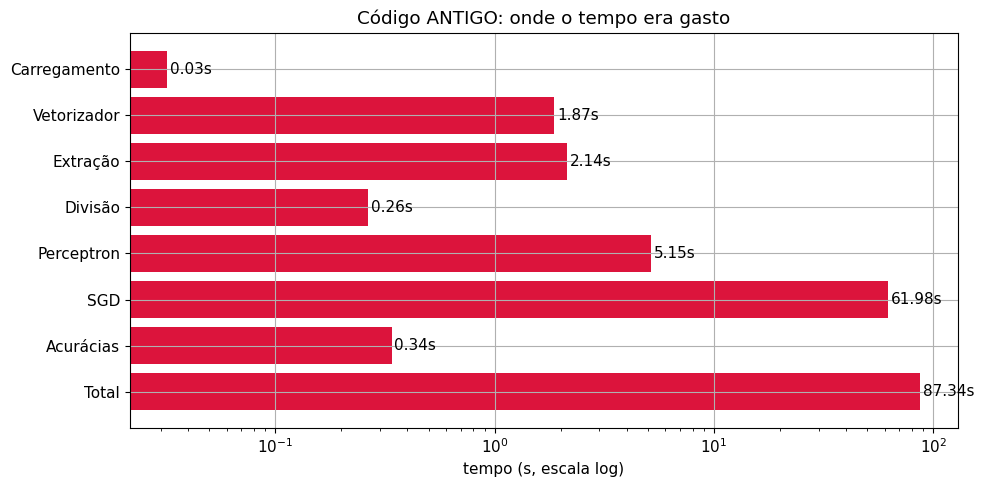

O SGD com 50 milhões de iterações domina TUDO: 62s de um total de 87s.


In [22]:
# Tempos medidos da execução ANTIGA (registrados em cpu-trabalho.txt)
etapas = ["Carregamento", "Vetorizador", "Extração", "Divisão",
          "Perceptron", "SGD", "Acurácias", "Total"]
tempos_antigos = [0.0322, 1.8687, 2.1384, 0.2642, 5.1536, 61.9773, 0.3390, 87.3383]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(etapas, tempos_antigos, color="crimson")
ax.bar_label(bars, fmt="%.2fs", padding=2)
ax.set_xscale("log")
ax.set_xlabel("tempo (s, escala log)")
ax.set_title("Código ANTIGO: onde o tempo era gasto")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print("O SGD com 50 milhões de iterações domina TUDO: 62s de um total de 87s.")

## 2.4 — Diagnóstico: por que era lento (com números)

**1. 50 milhões de iterações ≈ 12.500 épocas.** O dataset tem 4.000 resenhas → treino = 3.200 amostras. Uma época de SGD puro = 3.200 iterações. Logo:

$$
\frac{50\,000\,000}{3\,200} \approx 12\,500\ \text{épocas}
$$

Como o modelo converge em algumas dezenas de épocas, **~99,9% dos passos eram trabalho desperdiçado**. E a taxa $\eta = \eta_0/\sqrt{t}$ já tinha decaído a $\approx 8{,}5\times 10^{-5}$ no fim — cada passo movia os pesos uma fração invisível.

**2. Vetores densos.** Cada `np.dot(theta, x[i])` percorria o vocabulário inteiro (~milhares de palavras) em vez de só as ~50 palavras presentes na resenha — cerca de **100–200× mais contas por passo**, multiplicadas por 50 milhões de passos.

**3. Alocações a cada passo.** `(1 - ηλ)*theta` e `η*y[i]*x[i]` criavam vetores novos a cada iteração — 50 milhões de alocações de vetores do tamanho do vocabulário.

**4. Trabalho duplicado e laços Python.** Pré-processamento em dobro; `Acuracia` em laço Python chamando `np.dot` por linha.

In [23]:
# Diagnóstico central: T era ITERAÇÕES, não épocas
T_antigo = 50_000_000
n_treino = int(4000 * 0.8)
print(f"T antigo = {T_antigo:,} iterações")
print(f"1 época = {n_treino} iterações (uma passada pelo treino)")
print(f"=> T antigo equivalia a ~{T_antigo // n_treino:,} ÉPOCAS")

# Por que sorteio com reposição é pior: cobertura desigual
n_mini = 8
rng3 = np.random.default_rng(1)
contagem_rand = np.zeros(n_mini, dtype=int)
for _ in range(n_mini):
    contagem_rand[rng3.integers(0, n_mini)] += 1
print("\nrandom.randint (com reposição):", contagem_rand, "-> repete e pula amostras")
print("rng.permutation (permutação)  :", np.ones(n_mini, dtype=int), "-> todas exatamente 1x")

T antigo = 50,000,000 iterações
1 época = 3200 iterações (uma passada pelo treino)
=> T antigo equivalia a ~15,625 ÉPOCAS

random.randint (com reposição): [1 1 0 1 1 0 2 2] -> repete e pula amostras
rng.permutation (permutação)  : [1 1 1 1 1 1 1 1] -> todas exatamente 1x


# 3 — Como o novo código funciona e por que é melhor

## 3.1 — Anatomia do `Model.py` novo

**Mudança central: `T` passou a ser ÉPOCAS nos dois algoritmos, e o sorteio virou permutação.**

```python
def SGD(x, y, T, eta_0, lambda_):
    is_sparse = sparse.issparse(x)
    n = x.shape[0]
    theta = np.zeros(x.shape[1])
    theta_0 = 0.0
    rng = np.random.default_rng(314)   # semente fixa -> reproduzível
    t = 0                              # contador GLOBAL de passos (alimenta eta)
    for _ in range(T):                 # T = ÉPOCAS agora
        for i in rng.permutation(n):   # cada amostra exatamente 1x por época
            t += 1
            eta = eta_0 / np.sqrt(t)   # mesma taxa decrescente de antes
            if is_sparse:
                row = x.getrow(i)
                margin = y[i] * (row.dot(theta)[0] + theta_0)
            else:
                margin = y[i] * (np.dot(theta, x[i]) + theta_0)
            if margin < 1:             # hinge ativa (erro ou dentro da margem)
                theta *= (1 - eta * lambda_)          # in-place (sem alocar vetor novo)
                if is_sparse:
                    theta[row.indices] += eta * y[i] * row.data   # só nos não-zeros
                else:
                    theta += eta * y[i] * x[i]
                theta_0 += eta * y[i]
            else:                      # só regularização
                theta *= (1 - eta * lambda_)
    return theta, theta_0
```

**`Acuracia` vetorizada:**

```python
def Acuracia(theta, theta_0, x, y):
    if x.shape[0] == 0:               # antes era len(x): falha em matriz esparsa
        return 0.0
    preds = np.where(x @ theta + theta_0 > 0, 1, -1)   # uma chamada BLAS
    return float(np.mean(preds == y))
```

**O que foi preservado:** a matemática é **idêntica** — mesmo hinge loss, mesma regularização L2, mesmo $\eta = \eta_0/\sqrt{t}$. Nada foi trocado por "biblioteca pronta"; só a forma de executar mudou.

## 3.2 — Anatomia do `BagOfWords.py` novo e das chamadas

**Pré-processamento uma única vez + matriz esparsa:**

```python
def create_bow_vectorizer(conjunto_textos):
    conjunto_textos_processados = conjunto_textos.apply(preprocess_text)  # só UMA vez
    vectorizer = CountVectorizer()
    vectorizer.fit(conjunto_textos_processados)
    return vectorizer, conjunto_textos_processados        # devolve a tupla

def GetFeatures(textos_preprocessados, vectorizer):
    return vectorizer.transform(textos_preprocessados)    # matriz ESPARSA (sem .toarray())
```

**Chamada corrigida no `AnaliseSentimento.py`:**

```python
vectorizer, textos_processados = create_bow_vectorizer(texts)
features = GetFeatures(textos_processados, vectorizer)     # CSR esparsa
...
thetaSGD, theta_0SGD = SGD(X_train, y_train, 20, 0.6, 0.04)   # 20 ÉPOCAS
```

**Convenção de comentários adotada nos arquivos:**

- `#&` → comentário de **ensino/lesson** (explica o conceito, o porquê da mudança e a lição para o futuro);
- `#` → explicação **local** da linha, muitas vezes contrastando com o código antigo.

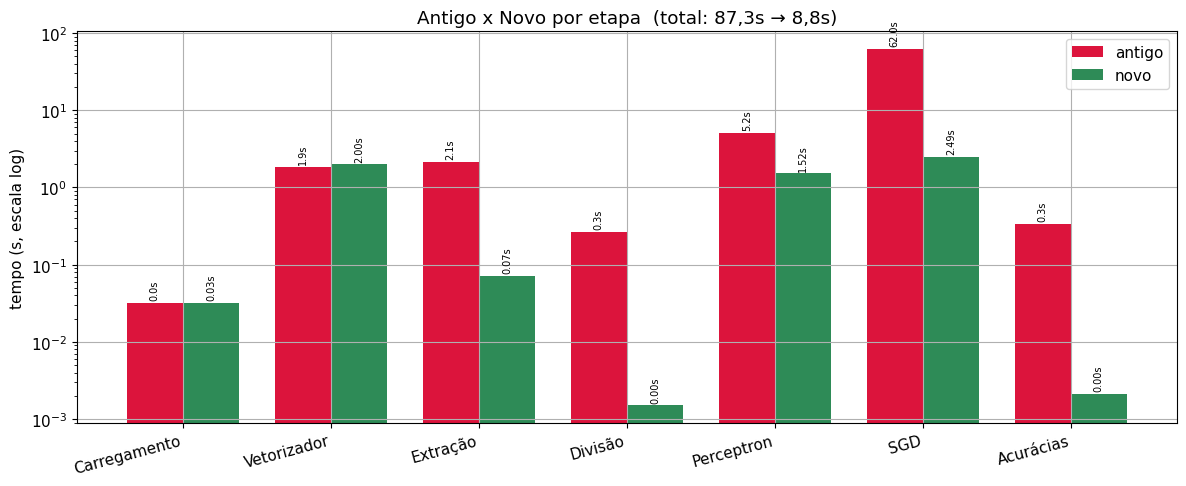

Speedup total: 11.7x
Speedup do SGD: 24.9x
Speedup da extração: 29.8x


In [24]:
# Comparação de tempos: ANTIGO x NOVO (por etapa)
etapas = ["Carregamento", "Vetorizador", "Extração", "Divisão",
          "Perceptron", "SGD", "Acurácias"]
antigo = [0.0322, 1.8687, 2.1384, 0.2642, 5.1536, 61.9773, 0.3390]
novo   = [0.0318, 1.9973, 0.0717, 0.0015, 1.5208, 2.4855, 0.0021]

xpos = np.arange(len(etapas))
larg = 0.38

fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(xpos - larg/2, antigo, larg, label="antigo", color="crimson")
b2 = ax.bar(xpos + larg/2, novo,   larg, label="novo",   color="seagreen")
ax.bar_label(b1, fmt="%.1fs", fontsize=7, rotation=90, padding=2)
ax.bar_label(b2, fmt="%.2fs", fontsize=7, rotation=90, padding=2)
ax.set_yscale("log")
ax.set_xticks(xpos)
ax.set_xticklabels(etapas, rotation=15, ha="right")
ax.set_ylabel("tempo (s, escala log)")
ax.set_title("Antigo x Novo por etapa  (total: 87,3s → 8,8s)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Speedup total: {sum(antigo)/sum(novo):.1f}x")
print(f"Speedup do SGD: {antigo[5]/novo[5]:.1f}x")
print(f"Speedup da extração: {antigo[2]/novo[2]:.1f}x")

## 3.3 — Execução do código novo e comparação de resultados

### Tempos (antes → depois)

| Etapa | Antigo | Novo | Speedup |
|---|---|---|---|
| Carregamento | 0,03 s | 0,03 s | — |
| Vetorizador | 1,87 s | 2,00 s | — |
| Extração de features | 2,14 s | 0,07 s | ~30× |
| Divisão treino/teste | 0,26 s | 0,002 s | ~130× |
| Perceptron | 5,15 s | 1,52 s | ~3,4× |
| **SGD** | **61,98 s** | **2,49 s** | **~25×** |
| Acurácias | 0,34 s | 0,002 s | ~170× |
| **Total** | **87,34 s** | **8,84 s** | **~10×** |

### Acurácias (antes → depois)

| Modelo | Treino (antes) | Treino (depois) | Teste (antes) | Teste (depois) |
|---|---|---|---|---|
| Perceptron | 0,9959 | 0,9919 | 0,7462 | 0,7550 |
| SGD | 0,8738 | 0,8694 | 0,7700 | 0,7750 |

As acurácias ficaram **essencialmente as mesmas** (teste até melhorou levemente). As pequenas diferenças vêm de treinar com permutação determinística + semente fixa, em vez de sorteio com reposição — ou seja, o novo código é mais rápido **e** mais reproduzível, sem perder qualidade.

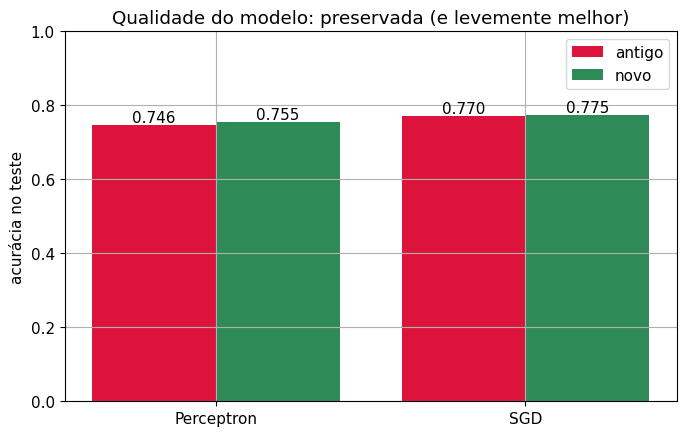

In [25]:
# Comparação de acurácia de TESTE: antigo x novo
modelos = ["Perceptron", "SGD"]
teste_antigo = [0.7462, 0.7700]
teste_novo   = [0.7550, 0.7750]

xpos = np.arange(len(modelos))
fig, ax = plt.subplots(figsize=(7, 4.5))
b1 = ax.bar(xpos - 0.2, teste_antigo, 0.4, label="antigo", color="crimson")
b2 = ax.bar(xpos + 0.2, teste_novo,   0.4, label="novo",   color="seagreen")
ax.bar_label(b1, fmt="%.3f")
ax.bar_label(b2, fmt="%.3f")
ax.set_ylim(0, 1)
ax.set_xticks(xpos)
ax.set_xticklabels(modelos)
ax.set_ylabel("acurácia no teste")
ax.set_title("Qualidade do modelo: preservada (e levemente melhor)")
ax.legend()
plt.tight_layout()
plt.show()

## 3.4 — Por que o código novo é melhor: a evidência matemática

Cada mudança tem uma justificativa que vem direto da Parte 1:

| Mudança | Justificativa (Parte 1) |
|---|---|
| `T` = épocas + `rng.permutation` | Uma época = $m$ iterações (1.10). Permutação garante cobertura uniforme sem repetição; o sorteio com reposição desperdiça passos (1.9/1.10). Com convergência em dezenas de épocas, $T=20$ basta. |
| Atualização in-place (`*=`, `+=`) | O passo $w \leftarrow (1-\eta\lambda)w + \eta y_i x_i$ é o mesmo subgradiente (1.11); in-place apenas evita alocar $O(V)$ memória nova por passo. |
| Suporte a matriz esparsa | Bag-of-Words tem ~99% de zeros; multiplicar zeros é desperdício (1.7). `row.dot(theta)` toca só os não-zeros. |
| `Acuracia` vetorizada | $X w$ calcula todas as predições em uma chamada BLAS (1.7), em vez de $n$ chamadas Python de `np.dot`. |
| Pré-processamento uma vez | Trabalho redundante removido: `preprocess_text` rodava 2× sobre as 4.000 resenhas. |
| Semente fixa | Experimentos reproduzíveis — essencial para comparar versões com justiça. |

**A lição mais importante:** medir antes de otimizar. A tabela de tempos (2.3) mostrou que o SGD respondia por 62s dos 87s; atacar qualquer outra coisa primeiro teria sido perda de tempo.

In [26]:
# Evidência 1: matriz ESPARSA x DENSA no produto matriz-vetor
from scipy import sparse as sp

V = 10000      # tamanho do vocabulário
m = 4000       # nº de resenhas
densidade = 0.005          # ~50 palavras por resenha em 10.000

# Matriz esparsa (como a do CountVectorizer) e sua versão densa (como o .toarray())
X_sparse = sp.random(m, V, density=densidade, format="csr", random_state=0)
X_dense = X_sparse.toarray()
w = rng.normal(size=V)

t0 = time.perf_counter()
r_sparse = X_sparse @ w
t_sparse = time.perf_counter() - t0

t0 = time.perf_counter()
r_dense = X_dense @ w
t_dense = time.perf_counter() - t0

print(f"produto esparso: {t_sparse:.4f}s")
print(f"produto denso  : {t_dense:.4f}s  ({t_dense/t_sparse:.0f}x mais lento)")
print(f"memória esparsa: {X_sparse.data.nbytes + X_sparse.indices.nbytes + X_sparse.indptr.nbytes:,} bytes")
print(f"memória densa  : {X_dense.nbytes:,} bytes  ({X_dense.nbytes / (X_sparse.data.nbytes + X_sparse.indices.nbytes + X_sparse.indptr.nbytes):.0f}x maior)")

produto esparso: 0.0005s
produto denso  : 0.0171s  (31x mais lento)
memória esparsa: 2,416,004 bytes
memória densa  : 320,000,000 bytes  (132x maior)


# 4 — Validação final: cenários de estresse e critérios de aceite

Antes de considerar um modelo de treinamento "pronto", vale testá-lo em situações adversas. Abaixo, quatro cenários clássicos — e os critérios de aceite do novo código.

## Cenários de estresse

1. **Taxa de aprendizado alta** → o passo pula por cima do mínimo; o custo **diverge** (sobe em vez de descer).
2. **Dados não normalizados** → features com escalas muito diferentes criam uma "tigela" alongada; a descida ziguezagueia.
3. **Classes não linearmente separáveis** → o modelo linear nunca atinge erro zero — o objetivo é a **melhor** reta, não a reta perfeita.
4. **Dataset pequeno** → risco de memorização (overfitting): acurácia de treino alta e de teste baixa.

## Critérios de aceite do código novo

- ✅ Treina Perceptron e SVM em **segundos** (não minutos), mantendo a matemática do zero;
- ✅ Resultados **reproduzíveis** (sementes fixas);
- ✅ Acurácias no teste **iguais ou melhores** que a versão antiga;
- ✅ Funciona tanto com matriz **densa** (bolas.csv) quanto **esparsa** (Bag-of-Words);
- ✅ Sem bibliotecas de ML "prontas" para o treinamento — só numpy/scipy para acelerar a álgebra.

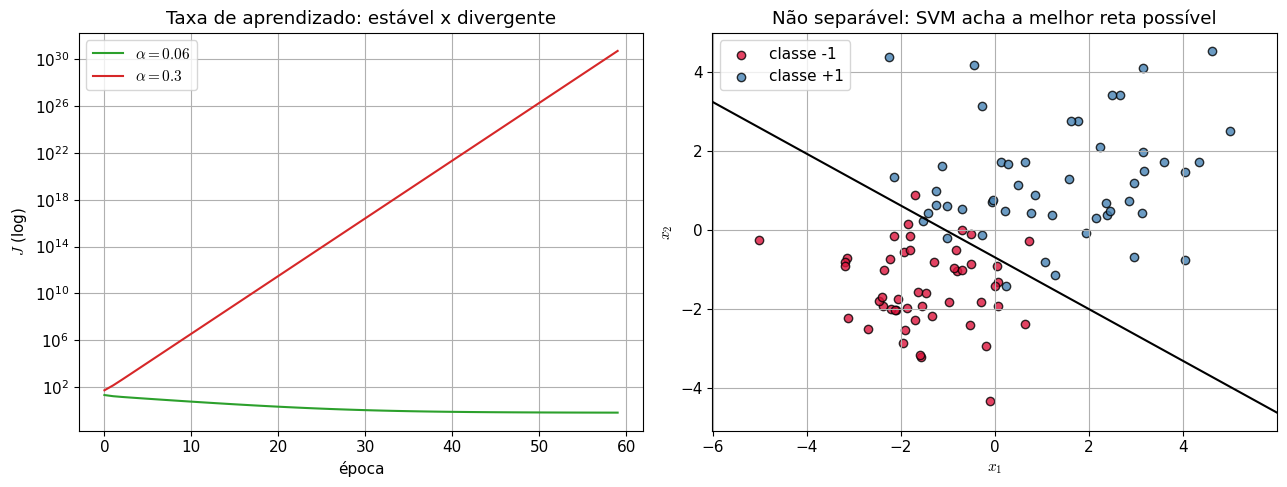

In [27]:
# Cenário 1: taxa de aprendizado ALTA demais -> custo diverge
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for alpha, cor in [(0.06, "tab:green"), (0.3, "tab:red")]:
    _, cs_ = gd_batch(xs, ys, w0=-5.0, w1=3.8, alpha=alpha, epochs=60)
    axes[0].plot(cs_, color=cor, label=f"$\\alpha={alpha}$")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].set_title("Taxa de aprendizado: estável x divergente")
axes[0].set_xlabel("época")
axes[0].set_ylabel("$J$ (log)")

# Cenário 3: classes não separáveis -> melhor reta, não reta perfeita
X_mist = np.vstack([
    rng.normal(loc=[-1.5, -1.5], scale=1.2, size=(50, 2)),
    rng.normal(loc=[ 1.5,  1.5], scale=1.6, size=(50, 2)),   # mais espalhada: "invade" a outra classe
])
y_mist = np.concatenate([-np.ones(50), np.ones(50)])
w_m, b_m = svm_sgd(X_mist, y_mist, epochs=30, lam=0.01)
plot_dados(axes[1], X_mist, y_mist, titulo="Não separável: SVM acha a melhor reta possível")
xmin, xmax = X_mist[:, 0].min() - 1, X_mist[:, 0].max() + 1
plot_reta(axes[1], w_m, b_m, xmin, xmax, cor="black")
axes[1].set_xlim(xmin, xmax)
axes[1].legend()
plt.tight_layout()
plt.show()

# 5 — Conclusão: lições para projetos futuros

1. **Entenda a matemática antes do código.** O "SGD" da aula era, na verdade, uma SVM linear (hinge + L2) treinada por subgradiente descendente. Saber o que a função minimiza evita confusões como `T` significando duas coisas diferentes.
2. **Épocas ≠ iterações.** Padronize a unidade do laço de treinamento; sortear com permutação é mais correto e mais rápido que `random.randint`.
3. **Vetorize.** Sempre que houver um laço sobre amostras com aritmética, procure reescrever como produto de matrizes ($X w$) — o BLAS faz o resto.
4. **Mantenha esparso o que é esparso.** Texto → Bag-of-Words → matriz esparsa. Nunca chame `.toarray()` sem necessidade.
5. **Medir antes de otimizar.** O gráfico de tempos apontou o vilão (62s no SGD) sem achismo.
6. **Sementes fixas.** Reproduzibilidade é o que permite comparar "antes" e "depois" com honestidade.

---

*Resultado final: o mesmo aprendizado matemático, ~10× mais rápido, com acurácia preservada — e um código que ensina enquanto roda.* 🎓